# IMDB Sentiment Analysis: From Bag-of-Words to Neural Classifiers

# PART 1: Classical Sentiment Classification

## Context

The IMDB dataset contains 50,000 movie reviews — 25,000 for training, 25,000 for testing, perfectly balanced between positive and negative.

## Stage 1: Data Loading 

**What to do:**
- The libraries below are pre-imported. Add anything else you need.
- Load the IMDB dataset using `load_dataset('imdb')` from HuggingFace.
- Extract train texts, test texts, and their labels into plain Python lists.
- Print the number of examples and class distribution.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [2]:
# Load the IMDB dataset
#from google.colab import userdata
#token = userdata.get('HF_Token')

#dataset     = load_dataset('stanfordnlp/imdb', token=token)
dataset     = load_dataset('stanfordnlp/imdb')
train_texts  = dataset['train']['text']
train_labels = dataset['train']['label']
test_texts   = dataset['test']['text']
test_labels  = dataset['test']['label']
y_train = np.array(train_labels)
y_test  = np.array(test_labels)

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [3]:
# Print number of examples and label distribution
print(f"Number of training examples-{len(train_texts)}")
print(f"Number of test examples-{len(test_texts)}")
print(f"Label Distribution-{np.bincount(train_labels)}")

Number of training examples-25000
Number of test examples-25000
Label Distribution-[12500 12500]


## Stage 2: Data Understanding

### 2.1 Class Distribution

Plot a bar chart of positive vs negative counts in the training set.

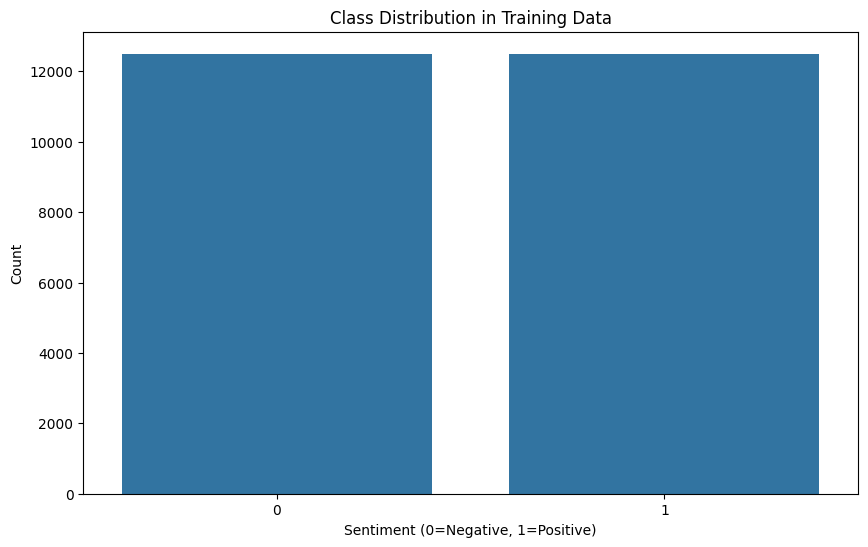

In [4]:
plt.figure(figsize=(10,6))
sns.countplot(x=train_labels)
plt.title("Class Distribution in Training Data")
plt.xlabel("Sentiment (0=Negative, 1=Positive)")
plt.ylabel("Count")
plt.show()

### 2.2 Review Length Distribution

Compute word count per training review. Plot a histogram and print the mean, median, and 95th percentile length.
Also plot lengths **separately for positive and negative reviews** using overlapping histograms.

Mean Length-233.7872
Median Length-174.0
95th percentile Length-598.0


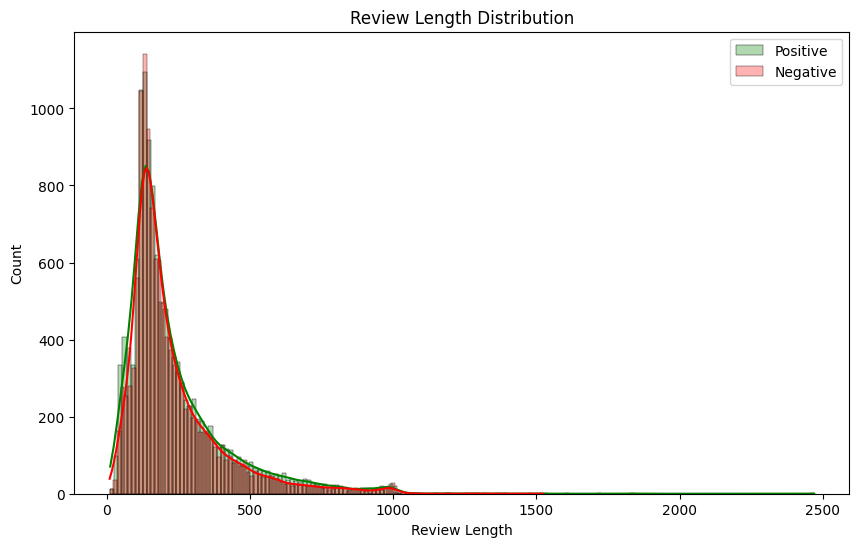

In [5]:
train_len = [len(text.split()) for text in train_texts]
print(f"Mean Length-{np.mean(train_len)}")
print(f"Median Length-{np.median(train_len)}")
print(f"95th percentile Length-{np.percentile(train_len, 95)}")

pos_rev_len = [length for index, length in enumerate(train_len) if train_labels[index] == 1]
neg_rev_len= [length for index, length in enumerate(train_len) if train_labels[index] == 0]

plt.figure(figsize=(10,6))
sns.histplot(pos_rev_len, label="Positive", color="green", alpha=0.3, kde=True)
sns.histplot(neg_rev_len, label="Negative", color="red", alpha=0.3, kde=True)
plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Count")
plt.legend()
plt.show()

### 2.3 Sample Reviews 

Print the first 200 characters of one positive and one negative review. Note any HTML artefacts you see.

In [6]:
#Print the first 200 characters of one positive and one negative review
pos_idx = next(i for i,label in enumerate(train_labels) if label==1)
neg_idx = next(i for i,label in enumerate(train_labels) if label==0)

print(f"Positive Review - {train_texts[pos_idx][:200]}")
print(f"Negative Review - {train_texts[neg_idx][:200]}")

Positive Review - Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emo
Negative Review - I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev


Fit a `CountVectorizer` (with `stop_words='english'`) on training data only.
Plot the top 20 most frequent words for positive reviews and negative reviews side by side.

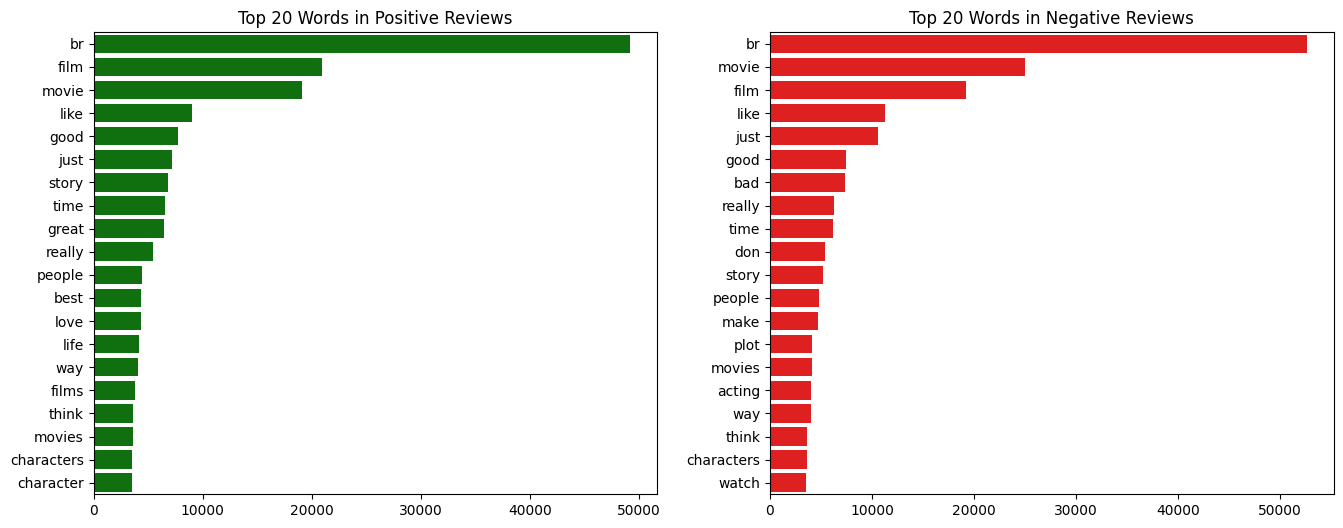

In [7]:
vector = CountVectorizer(stop_words="english")
pos_texts= [train_texts[i] for i, label in enumerate(train_labels) if label==1]
neg_texts= [train_texts[i] for i, label in enumerate(train_labels) if label==0]

def top_words(texts, n=20):
  matrix= vector.fit_transform(texts)
  word_sum= matrix.sum(axis=0)
  word_freq= [(word, word_sum[0, idx]) for word, idx in vector.vocabulary_.items()]
  return sorted(word_freq, key=lambda x: x[1], reverse=True)[:n]

pos_top_words= top_words(pos_texts)
neg_top_words= top_words(neg_texts)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=[x[1] for x in pos_top_words], y=[x[0] for x in pos_top_words], ax=axes[0], color='green')
axes[0].set_title("Top 20 Words in Positive Reviews")

sns.barplot(x=[x[1] for x in neg_top_words], y=[x[0] for x in neg_top_words], ax=axes[1], color='red')
axes[1].set_title("Top 20 Words in Negative Reviews")

plt.show()

Find 5 training reviews where `"not"` appears at least 3 times. Print the first 50 words of each and their true label.

> These are the examples classical models will get wrong most often.

In [8]:
negation_reviews = []
for i, text in enumerate(train_texts):
    if text.lower().count('not') >= 3:
        negation_reviews.append(i)

    if len(negation_reviews) == 5:
        break

for i in negation_reviews:
    print(f"Label: {train_labels[i]}")
    words = train_texts[i].split()
    first_50 = " ".join(words[:50])
    print(first_50 + "...")
    print("\n")

Label: 0
"I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, that isn't true. I've seen R-rated films with...


Label: 0
When I first saw a glimpse of this movie, I quickly noticed the actress who was playing the role of Lucille Ball. Rachel York's portrayal of Lucy is absolutely awful. Lucille Ball was an astounding comedian with incredible talent. To think about a legend like Lucille Ball being portrayed the...


Label: 0
Its not the cast. A finer group of actors, you could not find. Its not the setting. The director is in love with New York City, and by the end of the film, so are we all! Woody Allen could not improve upon what Bogdonovich has done here. If you...


Label: 0
Today I found "They All Laughed" on VHS on sale in a rental. It was a really old and very used VHS, I had no information a

## Stage 3: Preprocessing and Feature Engineering

## Binary One-Hot Vectors: The Simplest Text Representation

A **binary one-hot vector** represents a document as a fixed-length vector of 0s and 1s:

- **1** = this word appeared at least once in the review
- **0** = this word did not appear

For a vocabulary of 50,000 words, each review becomes a vector of 50,000 numbers, almost all of which are 0.

```python
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(binary=True, max_features=50000)
# binary=True → all non-zero counts become 1
# Each row: 1 if word present, 0 if absent — frequency ignored
```

**What one-hot cannot represent:**
- **Frequency** — `"bad"` appearing 10 times looks identical to `"bad"` appearing once
- **Rarity** — `"masterpiece"` (rare, diagnostic) has the same weight as `"film"` (common, uninformative)
- **Order** — `"not bad"` and `"bad not"` produce identical vectors

This is a deliberately weak representation. The classical models in Stage 4 will plateau around **80–84% F1** — well below what TF-IDF would give — leaving clear room for neural models to improve.

**Critical rule:** Fit the vectoriser on **training data only**. Fitting on test data leaks vocabulary statistics into training.

### 3.1 Text Cleaning  

`clean_text(text)` function that:
- Removes HTML tags (`<br />`, `<b>`, etc.) using a regex
- Lowercases the text
- Strips leading/trailing whitespace

Apply it to all train and test texts. Print a before/after example to confirm it works.

In [9]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    return text.lower().strip()

# Apply to train and test
train_texts_clean = [clean_text(text) for text in train_texts]
test_texts_clean = [clean_text(text) for text in test_texts]

# Print one before/after example
print("--- Before ---")
print(train_texts[0][:100])
print("\n--- After ---")
print(train_texts_clean[0][:100])

--- Before ---
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it w

--- After ---
i rented i am curious-yellow from my video store because of all the controversy that surrounded it w


### 3.2 Build One-Hot Features

Create a `CountVectorizer` with:
- `binary=True` — converts all counts to 0/1
- `max_features=50000` — keep the 50,000 most frequent words
- `min_df=5` — ignore words appearing in fewer than 5 reviews
- `stop_words='english'`

**Fit on training data only**, then transform both splits. Print the shape and sparsity of the resulting matrices.

> **Note:** No `ngram_range=(1,2)` this time — with one-hot, bigrams would double the already-large feature space with minimal benefit. Unigrams only.

In [10]:
vectorizer = CountVectorizer(
    binary=True,
    max_features=50000,
    min_df=5,
    stop_words='english'
)
X_train = vectorizer.fit_transform(train_texts_clean)
X_test = vectorizer.transform(test_texts_clean)
print(f"Shape of training matrix: {X_train.shape}")
sparsity = (X_train.nnz / (X_train.shape[0] * X_train.shape[1])) * 100
print(f"Sparsity of training matrix: {sparsity:.4f}%")

Shape of training matrix: (25000, 26958)
Sparsity of training matrix: 0.3189%


## Helper: Evaluation Function

Define a reusable `evaluate_model(name, y_true, y_pred)` function. It should:
- Print accuracy, F1, precision, recall
- Print a `classification_report`
- Plot a confusion matrix heatmap
- Return the metrics as a dict (for building a comparison table later)

In [11]:
def evaluate_model(name, y_true, y_pred):
    print(f"{name} Results")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

## Using Pipeline + GridSearchCV for Text

Chain the vectoriser and classifier in a `Pipeline`, then wrap in `GridSearchCV`. This ensures the vectoriser is re-fit on each cross-validation fold — preventing data leakage.

```python
pipe = Pipeline([
    ('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')),
    ('clf', LogisticRegression(random_state=42))
])
param_grid = {
    'vec__max_features': [20000, 50000],   # prefix is the pipeline step name
    'clf__C':            [0.1, 1, 10]
}
grid = GridSearchCV(pipe, param_grid, scoring='f1', cv=5, n_jobs=-1)
grid.fit(train_texts_clean, y_train)   # pass CLEANED TEXT — not the matrix
```

> **Important:** Pass cleaned raw text to `grid.fit()`. The pipeline applies the vectoriser internally at each fold, which is what prevents leakage.

## Stage 4: Model Training, Tuning, and Evaluation

Train **four classifiers**. For each: build a Pipeline with a `CountVectorizer(binary=True, ...)`, run GridSearchCV with `scoring='f1'` and `cv=5`, print best params and CV score, then evaluate on the test set using `evaluate_model()`.

> **Expected F1 range:** ~78–84%. One-hot vectors give no frequency or rarity information, so classical models cannot achieve the same ceiling as TF-IDF. This is deliberate — it leaves meaningful room for neural models to improve.

### 4.1 Logistic Regression
Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__C`: `[0.01, 0.1, 1, 10]`

Set `max_iter=1000`, `random_state=42`.

In [12]:
pipe_lr = Pipeline([
    ('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {
    'vec__max_features': [20000, 50000],
    'clf__C': [0.01, 0.1, 1, 10]
}

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, scoring='f1', cv=5, n_jobs=-1)
grid_lr.fit(train_texts_clean, y_train)

print(f"Best Params: {grid_lr.best_params_}")
print(f"Best CV F1: {grid_lr.best_score_:.4f}")

Best Params: {'clf__C': 0.01, 'vec__max_features': 20000}
Best CV F1: 0.8663


Logistic Regression Results
Accuracy: 0.8733
F1 Score: 0.8746
Precision: 0.8656
Recall: 0.8838

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87     12500
           1       0.87      0.88      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



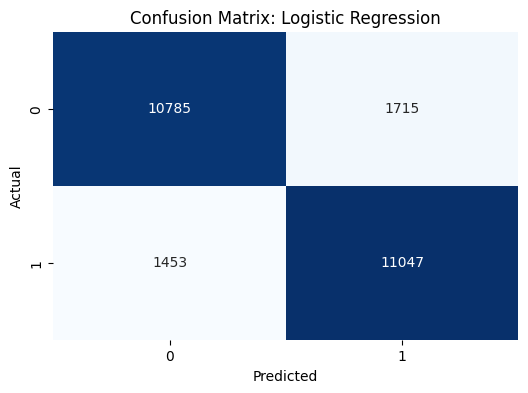

In [13]:
# Predict on test set and evaluate
y_pred_lr = grid_lr.predict(test_texts_clean)
metrics_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr)

### 4.2 Bernoulli Naive Bayes 

Use `BernoulliNB` — the variant of Naive Bayes designed specifically for **binary features**. It models each word as a Bernoulli (present/absent) trial, which matches our one-hot representation exactly.

Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__alpha`: `[0.01, 0.1, 0.5, 1.0]`

> **Why BernoulliNB and not ComplementNB?** `ComplementNB` is designed for count features. `BernoulliNB` is the correct choice for binary presence/absence data — it penalises words that are *absent* from a class, which is meaningful when features are truly binary.

In [14]:

pipe_nb = Pipeline([
    ('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')),
    ('clf', BernoulliNB())
])

param_grid_nb = {
    'vec__max_features': [20000, 50000],
    'clf__alpha': [0.01, 0.1, 0.5, 1.0]
}

# Grid Search
grid_nb = GridSearchCV(pipe_nb, param_grid_nb, scoring='f1', cv=5, n_jobs=-1)
grid_nb.fit(train_texts_clean, y_train)

print(f"Best Params: {grid_nb.best_params_}")
print(f"Best CV F1: {grid_nb.best_score_:.4f}")

Best Params: {'clf__alpha': 1.0, 'vec__max_features': 20000}
Best CV F1: 0.7982


Bernoulli Naive Bayes Results
Accuracy: 0.8232
F1 Score: 0.8116
Precision: 0.8685
Recall: 0.7617

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83     12500
           1       0.87      0.76      0.81     12500

    accuracy                           0.82     25000
   macro avg       0.83      0.82      0.82     25000
weighted avg       0.83      0.82      0.82     25000



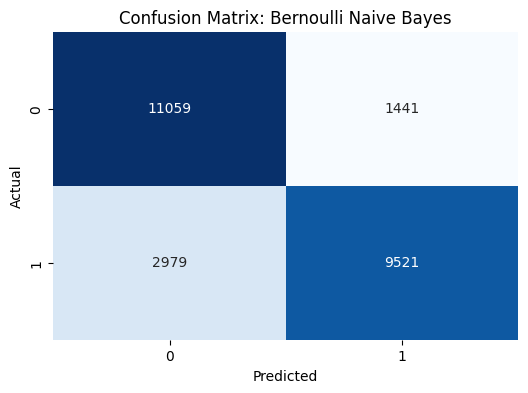

In [15]:
y_pred_nb = grid_nb.predict(test_texts_clean)
metrics_nb = evaluate_model("Bernoulli Naive Bayes", y_test, y_pred_nb)

### 4.3 LinearSVC

Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__C`: `[0.01, 0.1, 1, 10]`

Set `random_state=42`, `max_iter=2000`.

In [16]:
pipe_svc = Pipeline([
    ('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')),
    ('clf', LinearSVC(random_state=42, max_iter=2000, dual="auto"))
])

param_grid_svc = {
    'vec__max_features': [20000, 50000],
    'clf__C': [0.01, 0.1, 1, 10]
}

grid_svc = GridSearchCV(pipe_svc, param_grid_svc, scoring='f1', cv=5, n_jobs=-1)
grid_svc.fit(train_texts_clean, y_train)

print(f"Best Params: {grid_svc.best_params_}")
print(f"Best CV F1: {grid_svc.best_score_:.4f}")

Best Params: {'clf__C': 0.01, 'vec__max_features': 50000}
Best CV F1: 0.8620


LinearSVC Results
Accuracy: 0.8741
F1 Score: 0.8745
Precision: 0.8714
Recall: 0.8777

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87     12500
           1       0.87      0.88      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



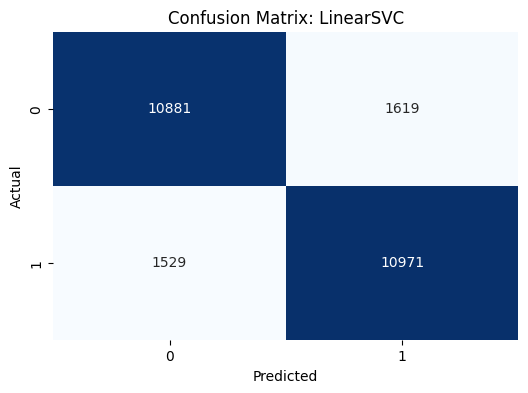

In [17]:
y_pred_svc = grid_svc.predict(test_texts_clean)
metrics_svc = evaluate_model("LinearSVC", y_test, y_pred_svc)

### 4.4 Random Forest

Random Forest builds many decision trees on random subsets of features and takes a majority vote. It handles high-dimensional sparse binary vectors well and naturally produces **feature importances** — making it ideal for Stage 5.3.

Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__n_estimators`: `[100, 200]`
- `clf__max_depth`: `[None, 20, 50]`
- `clf__min_samples_leaf`: `[1, 2]`

Set `random_state=42`, `n_jobs=-1`.

> **Note:** Random Forest is slower than LR or SVM on this dataset — expect ~2–3 minutes. This is normal.

In [18]:
pipe_rf = Pipeline([
    ('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid_rf = {
    'vec__max_features': [20000, 50000],
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 20, 50],
    'clf__min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(pipe_rf, param_grid_rf, scoring='f1', cv=5, n_jobs=-1)
grid_rf.fit(train_texts_clean, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('vec',
                                        CountVectorizer(binary=True, min_df=5,
                                                        stop_words='english')),
                                       ('clf',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__max_depth': [None, 20, 50],
                         'clf__min_samples_leaf': [1, 2],
                         'clf__n_estimators': [100, 200],
                         'vec__max_features': [20000, 50000]},
             scoring='f1')

Random Forest Results
Accuracy: 0.8549
F1 Score: 0.8550
Precision: 0.8541
Recall: 0.8560

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85     12500
           1       0.85      0.86      0.86     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



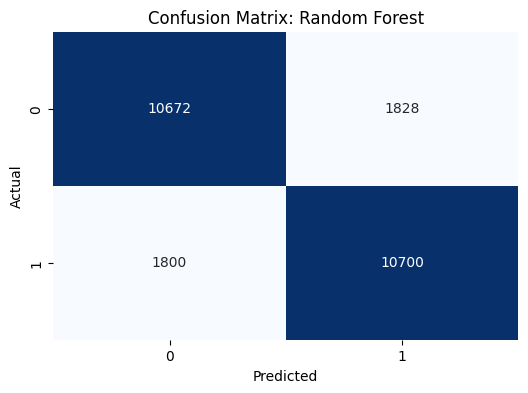

In [19]:
y_pred_rf = grid_rf.predict(test_texts_clean)
metrics_rf = evaluate_model("Random Forest", y_test, y_pred_rf)

## Stage 5: Classical Model Comparison

### 5.1 Comparison Table 

Build a DataFrame comparing all four models on Accuracy, Precision, Recall, and F1. Sort by F1 descending.

In [20]:
results_list = [metrics_lr, metrics_nb, metrics_svc, metrics_rf]
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by='F1', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.87328,0.865617,0.88376,0.874594
2,LinearSVC,0.87408,0.871406,0.87768,0.874532
3,Random Forest,0.85488,0.854087,0.85600,0.855042
1,Bernoulli Naive Bayes,0.82320,0.868546,0.76168,0.811610


### 5.2 Visualise  

Grouped bar chart comparing Precision, Recall, and F1 across all four models.

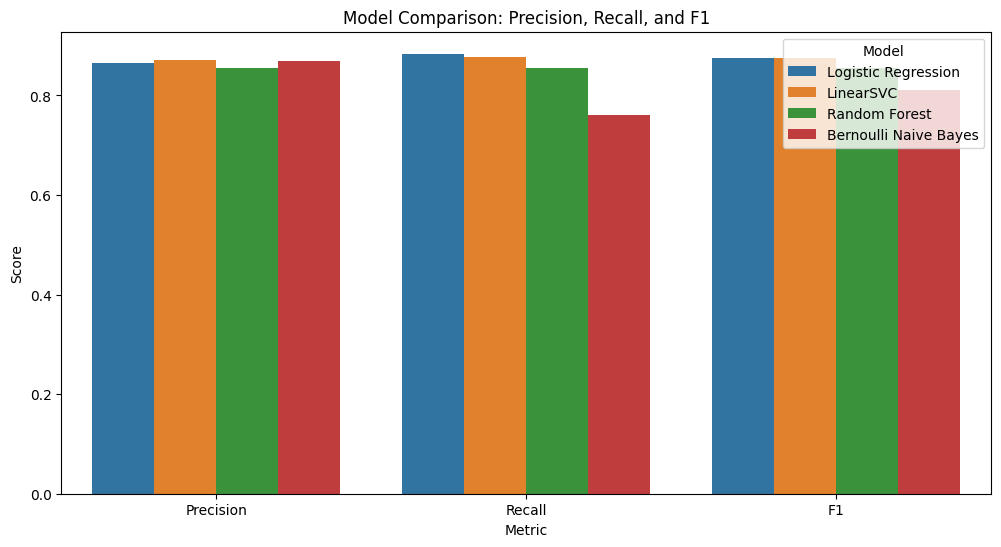

In [21]:
df_melted = results_df.melt(
    id_vars="Model",
    value_vars=["Precision", "Recall", "F1"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model")
plt.title("Model Comparison: Precision, Recall, and F1")
plt.show()

### 5.3 Most Important Features 

From the **Random Forest** pipeline, extract the top 20 most important words using `.feature_importances_`.

Plot them as a horizontal bar chart sorted by importance.

> **Note:** Random Forest importance is non-negative (unlike LR/SVM coefficients) — you cannot separate positive/negative direction. Instead, these are the words that most reduced impurity across all trees, regardless of direction. The most important words should be strong sentiment markers.

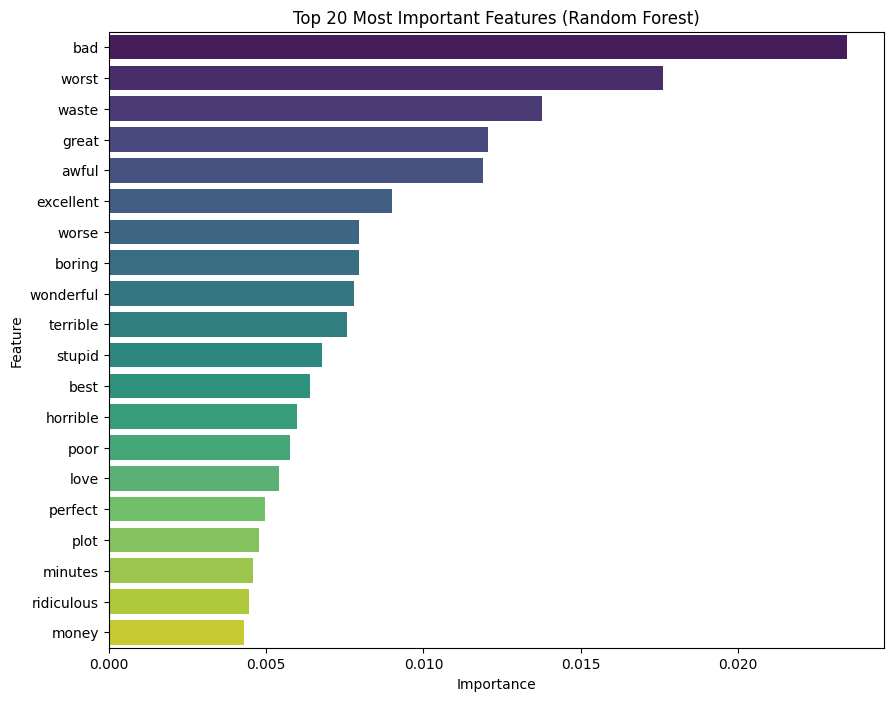

In [22]:
best_rf = grid_rf.best_estimator_.named_steps['clf']
feature_names = grid_rf.best_estimator_.named_steps['vec'].get_feature_names_out()
importances = best_rf.feature_importances_
feat_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_importances = feat_importances.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_importances, x='Importance', y='Feature', palette='viridis')
plt.title("Top 20 Most Important Features (Random Forest)")
plt.show()

In [23]:
# Find and print 3 misclassified reviews from your best model
y_pred = grid_lr.predict(test_texts_clean)

wrong_indices = [i for i, (true, pred) in enumerate(zip(y_test, y_pred)) if true != pred]

for i in wrong_indices[:3]:
    print(f"True Label: {y_test[i]} and Predicted: {y_pred[i]}")
    words = test_texts_clean[i].split()
    first_30 = " ".join(words[:30])
    print(f"Review: {first_30}...")
    print("-" * 30)

True Label: 0 and Predicted: 1
Review: worth the entertainment value of a rental, especially if you like action movies. this one features the usual car chases, fights with the great van damme kick style, shooting battles...
------------------------------
True Label: 0 and Predicted: 1
Review: first off let me say, if you haven't enjoyed a van damme movie since bloodsport, you probably will not like this movie. most of these movies may not have the...
------------------------------
True Label: 0 and Predicted: 1
Review: blind date (columbia pictures, 1934), was a decent film, but i have a few issues with this film. first of all, i don't fault the actors in this film at...
------------------------------


---
# PART 2: Neural Sentiment Classifiers

## Context

Classical models with one-hot vectors have three fundamental weaknesses:
1. **No frequency** — `"bad"` appearing once = `"bad"` appearing ten times
2. **No rarity signal** — `"film"` (meaningless) has the same weight as `"masterpiece"` (highly diagnostic)
3. **No word order** — `"not bad"` and `"bad not"` are identical vectors

Neural sequence models address all three. They learn dense word representations (embeddings) that encode meaning, and process tokens sequentially or with attention to capture context.

## New NLP Concepts for Part 2

You know neural networks. Here is what is new when applying them to text:

### 1. Tokenisation and vocabulary
Instead of TF-IDF vectors, we convert each review to a **sequence of integer IDs**:
```
"not bad"  →  tokenise  →  ['not', 'bad']  →  map to IDs  →  [45, 312]
```
A **vocabulary** maps every known training word to a unique integer. Unknown words → `<UNK>` (ID 1). The padding token `<PAD>` (ID 0) is used to fill short sequences.

### 2. Padding and truncation
All sequences in a batch must be the same length. We fix every review to `MAX_LEN = 400`:
- Reviews longer than 400 tokens → keep the first 400 (truncate)
- Reviews shorter than 400 tokens → append zeros on the right (pad)

### 3. Embedding layer
`nn.Embedding(vocab_size, dim)` is a learnable lookup table. Row $i$ is the vector for word ID $i$. Unlike TF-IDF (sparse, one feature per word), embeddings are **dense** (e.g. 100 floats per word) and **learned from data**.
```python
self.embedding = nn.Embedding(vocab_size, 128, padding_idx=0)
# padding_idx=0 → PAD tokens get a zero vector and don't affect gradients
```

### 4. Binary classification output
The model outputs **one logit per review** (not two — this is binary). Loss is `BCEWithLogitsLoss`.
Prediction: `sigmoid(logit) > 0.5` → class 1 (positive), else class 0 (negative).

## Stage 1: Setup

All cells in this stage run them in order, read the comments, and make sure you understand what each part does before moving to Stage 2A.

In [24]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import math
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  device: {device}')
if device.type == 'cpu':
    print('Tip: enable a GPU runtime in Google Colab (Runtime → Change runtime type → T4 GPU)')

torch.manual_seed(42)
np.random.seed(42)

PyTorch 2.11.0+cu128  |  device: cuda


In [25]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
# TOKENISER: strips HTML, lowercases, removes punctuation, splits on spaces.
def tokenize(text):
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()

# VOCABULARY: built from training data only.
# Words appearing fewer than MIN_FREQ times are treated as unknown (<UNK>).
MIN_FREQ = 5
counter  = Counter()
for doc in train_texts:
    counter.update(tokenize(doc))

word2idx = {'<PAD>': 0, '<UNK>': 1}
for word, freq in counter.items():
    if freq >= MIN_FREQ:
        word2idx[word] = len(word2idx)

idx2word   = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)
print(f'Vocabulary: {VOCAB_SIZE:,} words  (words seen < {MIN_FREQ}× → <UNK>)')

Vocabulary: 29,123 words  (words seen < 5× → <UNK>)


In [26]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
# DATASET: converts a raw review + label into a fixed-length integer tensor.
MAX_LEN    = 400   # reviews longer than this are truncated; shorter ones are padded
BATCH_SIZE = 64

class IMDBDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len):
        self.labels = labels
        self.seqs   = []
        for doc in texts:
            ids  = [word2idx.get(t, 1) for t in tokenize(doc)]  # unknown → 1
            ids  = ids[:max_len]                                  # truncate
            ids += [0] * (max_len - len(ids))                    # pad with 0
            self.seqs.append(ids)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (torch.tensor(self.seqs[idx],   dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.float))

train_ds = IMDBDataset(train_texts, y_train, word2idx, MAX_LEN)
test_ds  = IMDBDataset(test_texts,  y_test,  word2idx, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
print(f'Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}')

Train batches: 391  |  Test batches: 391


In [27]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
# TRAINING LOOP — do not modify.
def train_model(model, dataloader, optimizer, criterion, device,
                n_epochs=10, scheduler=None):
    model.to(device)
    epoch_losses = []
    for epoch in range(1, n_epochs + 1):
        model.train()
        total = 0
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(X).squeeze(1)          # (batch,)
            loss   = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total += loss.item()
        if scheduler:
            scheduler.step()
        avg = total / len(dataloader)
        epoch_losses.append(avg)
        print(f'  Epoch {epoch:>2}/{n_epochs}  |  Loss: {avg:.4f}')
    return epoch_losses


# EVALUATION LOOP — do not modify.
def evaluate_neural(model, dataloader, device, name='Model'):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in dataloader:
            out  = torch.sigmoid(model(X.to(device)).squeeze(1))
            pred = (out > 0.5).long().cpu().numpy()
            all_preds.extend(pred)
            all_labels.extend(y.numpy().astype(int))
    preds, labels = np.array(all_preds), np.array(all_labels)
    print(f'\n=== {name} ===')
    print(f'  Accuracy  : {accuracy_score(labels, preds):.4f}')
    print(f'  F1        : {f1_score(labels, preds):.4f}')
    print(f'  Precision : {precision_score(labels, preds):.4f}')
    print(f'  Recall    : {recall_score(labels, preds):.4f}')
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
    plt.title(name); plt.tight_layout(); plt.show()
    return preds, labels


# UTILITIES
def plot_losses(losses, title):
    plt.figure(figsize=(7, 3))
    plt.plot(range(1, len(losses)+1), losses, marker='o')
    plt.title(title); plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

def count_params(model):
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Trainable parameters: {n:,}')
    return n

print('All helpers ready.')

All helpers ready.


## Stage 2A: Vanilla RNN 

## How an RNN Processes a Review

An RNN reads the review **one token at a time**, left to right. At each step $t$:

$$h_t = \tanh(W_h \cdot h_{t-1} + W_x \cdot x_t + b)$$

- $x_t$ = embedding of the current token (a 128-dim vector)
- $h_{t-1}$ = hidden state from the previous step (memory of what came before)
- $h_t$ = updated hidden state

After reading all 400 tokens, the **final hidden state** $h_{400}$ is the model's summary of the whole review. It is then passed to a linear classifier.

**The vanishing gradient problem:** To learn from token 1, the gradient must travel back through 400 steps. Each step multiplies the gradient by the weight matrix $W_h$. If $\|W_h\| < 1$, the gradient shrinks exponentially — by the time it reaches token 1 it is essentially zero. The model cannot learn anything from distant context. You will see this in the loss curve: the RNN stalls early.

```python
self.rnn = nn.RNN(
    input_size  = embedding_dim,   # size of each input token embedding
    hidden_size = hidden_dim,      # size of hidden state h_t
    num_layers  = 2,               # stack 2 RNN layers
    batch_first = True,            # input shape: (batch, seq_len, embed_dim)
    dropout     = 0.3              # dropout between layers (only applies if num_layers > 1)
)
# rnn(embeddings) returns: (output, h_n)
#   output: (batch, seq_len, hidden_dim) — every hidden state
#   h_n:    (num_layers, batch, hidden_dim) — only the last step
# For classification we take h_n[-1]: the last layer's final hidden state.
```

### 2A.1 Build the RNN Model  

The `RNNSentiment` class. Architecture:

```
Input: token IDs, shape (batch, 400)
  ↓
nn.Embedding(vocab_size, 128, padding_idx=0)   ← learnable word vectors
  ↓
nn.RNN(128, 256, num_layers=2, dropout=0.3, batch_first=True)
  ↓
h_n[-1]    ← final hidden state, shape (batch, 256)
  ↓
nn.Dropout(0.5)
  ↓
nn.Linear(256, 1)   ← single logit output (no sigmoid — BCEWithLogitsLoss handles that)
```

**Step-by-step hints for `forward`:**
1. Pass `x` through the embedding layer → shape `(batch, 400, 128)`
2. Pass embeddings through the RNN → unpack as `output, h_n = self.rnn(emb)`
3. Take `h_n[-1]` → shape `(batch, 256)`
4. Apply dropout, then the linear layer

In [28]:
class RNNSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        # Define: embedding, rnn, dropout, fc
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, num_layers=num_layers,
                          dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # 1. Embed tokens
        embedded = self.embedding(x)

        # 2. Pass through RNN, get h_n
        _, h_n = self.rnn(embedded)

        # 3. h_n[-1] → dropout → linear
        out = h_n[-1]
        out = self.dropout(out)
        return self.fc(out)

### 2A.2 Train and Evaluate  

  Trainable parameters: 3,958,401
Training RNN...
  Epoch  1/10  |  Loss: 0.6997
  Epoch  2/10  |  Loss: 0.6981
  Epoch  3/10  |  Loss: 0.6979
  Epoch  4/10  |  Loss: 0.6981
  Epoch  5/10  |  Loss: 0.6984
  Epoch  6/10  |  Loss: 0.6987
  Epoch  7/10  |  Loss: 0.6975
  Epoch  8/10  |  Loss: 0.6986
  Epoch  9/10  |  Loss: 0.6986
  Epoch 10/10  |  Loss: 0.6989


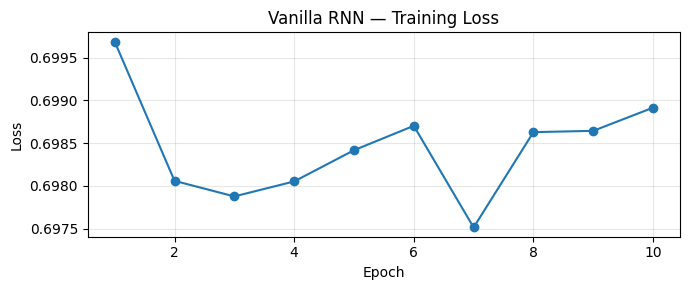


=== Vanilla RNN ===
  Accuracy  : 0.4978
  F1        : 0.5116
  Precision : 0.4979
  Recall    : 0.5261


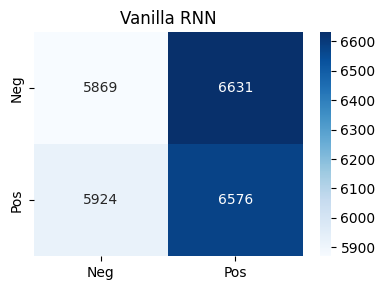

In [29]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
rnn_model     = RNNSentiment(VOCAB_SIZE)
count_params(rnn_model)
optimizer_rnn = optim.Adam(rnn_model.parameters(), lr=1e-3)
criterion     = nn.BCEWithLogitsLoss()

print('Training RNN...')
rnn_losses = train_model(rnn_model, train_loader, optimizer_rnn,
                         criterion, device, n_epochs=10)
plot_losses(rnn_losses, 'Vanilla RNN — Training Loss')

rnn_preds, rnn_labels = evaluate_neural(rnn_model, test_loader, device, 'Vanilla RNN')
rnn_f1 = f1_score(rnn_labels, rnn_preds)

## Stage 2B: LSTM 

## How the LSTM Fixes the Vanishing Gradient

The LSTM adds a second vector: the **cell state** $c_t$. Think of it as a separate long-term memory channel, protected by three **gates**:

| Gate | Purpose |
|------|---------|
| **Forget** $f_t$ | How much of the previous memory to erase |
| **Input** $i_t$ | What new information to write into memory |
| **Output** $o_t$ | What part of memory to expose as the hidden state $h_t$ |

$$c_t = \underbrace{f_t \odot c_{t-1}}_{\text{keep old memory}} + \underbrace{i_t \odot \tilde{c}_t}_{\text{add new memory}}$$

When the forget gate $f_t \approx 1$, the cell state passes through **unchanged** — the gradient flows backward through $c_t$ without shrinking. This is the gradient highway that vanilla RNNs lack.

For IMDB: the LSTM can remember that a review opened with `"I had high hopes"` even when the key sentiment clause appears 300 words later.

```python
self.lstm = nn.LSTM(
    input_size=embedding_dim, hidden_size=hidden_dim,
    num_layers=2, batch_first=True, dropout=0.3
)
# LSTM returns: (output, (h_n, c_n))   ← note the nested tuple!
# Unpack like this:
output, (h_n, c_n) = self.lstm(emb)
# h_n[-1] is still the last layer's final hidden state — same as the RNN.
```

### 2B.1 Build the LSTM Model

The architecture is **identical to the RNN** — only replace `nn.RNN` with `nn.LSTM`:

```
Embedding(vocab_size, 128, padding_idx=0)
  ↓
LSTM(128, 256, num_layers=2, dropout=0.3, batch_first=True)
  ↓
h_n[-1]    ← (batch, 256)
  ↓
Dropout(0.5)
  ↓
Linear(256, 1)
```

**The only code difference from the RNN:**
- Use `nn.LSTM` instead of `nn.RNN`
- Unpack as `_, (h_n, _) = self.lstm(emb)` — the second return value is a tuple `(h_n, c_n)`

In [30]:
class LSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        # Define: embedding, lstm, dropout, fc
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers,
                            dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # 1. Embed tokens
        embedded = self.embedding(x)

        # 2. LSTM — unpack (output, (h_n, c_n))
        _, (h_n, _) = self.lstm(embedded)

        # 3. h_n[-1] → dropout → linear
        out = h_n[-1]
        out = self.dropout(out)
        return self.fc(out)

  Trainable parameters: 4,649,601
Training LSTM...
  Epoch  1/10  |  Loss: 0.6933
  Epoch  2/10  |  Loss: 0.6888
  Epoch  3/10  |  Loss: 0.6711
  Epoch  4/10  |  Loss: 0.6360
  Epoch  5/10  |  Loss: 0.6095
  Epoch  6/10  |  Loss: 0.5977
  Epoch  7/10  |  Loss: 0.6017
  Epoch  8/10  |  Loss: 0.5877
  Epoch  9/10  |  Loss: 0.5334
  Epoch 10/10  |  Loss: 0.4127


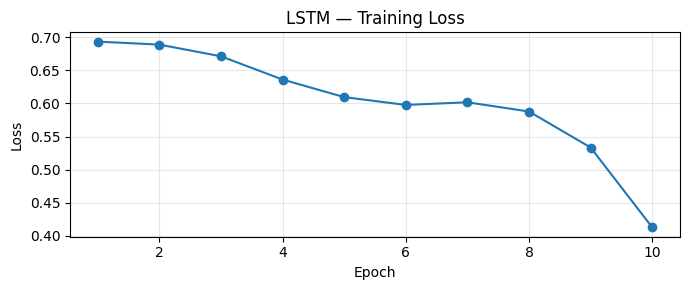


=== LSTM ===
  Accuracy  : 0.8016
  F1        : 0.8043
  Precision : 0.7935
  Recall    : 0.8154


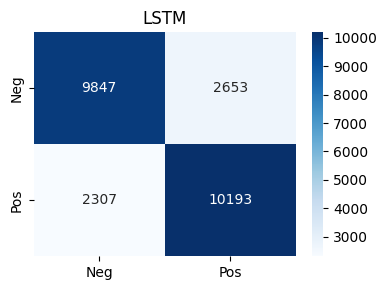

In [31]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
lstm_model     = LSTMSentiment(VOCAB_SIZE)
count_params(lstm_model)
optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=1e-3)

print('Training LSTM...')
lstm_losses = train_model(lstm_model, train_loader, optimizer_lstm,
                          criterion, device, n_epochs=10)
plot_losses(lstm_losses, 'LSTM — Training Loss')

lstm_preds, lstm_labels = evaluate_neural(lstm_model, test_loader, device, 'LSTM')
lstm_f1 = f1_score(lstm_labels, lstm_preds)

## Stage 2C: Bidirectional LSTM + FastText Embeddings

## Two Improvements at Once

### Bidirectional LSTM

A standard LSTM reads left-to-right. Consider:

> *"A film that, despite its slow start, delivers a genuinely moving finale."*

When the LSTM reaches `"slow"` it has not yet seen `"moving"` or `"finale"`. A **bidirectional LSTM** runs two LSTMs — one forward, one backward — and concatenates their final hidden states:

```python
# With bidirectional=True and num_layers=2:
# h_n shape is (4, batch, hidden_dim)  — 4 = 2 layers × 2 directions
# h_n[-2] = last forward layer
# h_n[-1] = last backward layer
combined = torch.cat([h_n[-2], h_n[-1]], dim=1)  # (batch, hidden_dim * 2)
```
The hidden dimension **doubles**: 256 → 512.

### FastText Pre-trained Embeddings

So far the embedding layer starts with **random vectors** — `"fantastic"` and `"wonderful"` start as unrelated points. The model must learn their similarity purely from sentiment labels.

**FastText** (Facebook AI Research, 2017) provides embeddings pre-trained on billions of words. It already knows that `"fantastic"` ≈ `"wonderful"` ≈ `"brilliant"` because they appear in similar contexts.

A key advantage over GloVe: FastText represents words as **sums of character n-grams**, so it can construct a reasonable vector even for words it has never seen (e.g. typos, rare words).

Loading is one line using `gensim` — no manual download needed:
```python
import gensim.downloader as api
ft_model = api.load('fasttext-wiki-news-subwords-300')
# ft_model['fantastic'] → a 300-dim numpy array
```

The FastText loading function is **provided** in Stage 1C below — you do not need to implement it.

### Stage 1C: Load FastText Embeddings 

This cell downloads and caches FastText embeddings using `gensim`. It runs once and caches locally — subsequent runs are fast.

> **Note:** The download is ~1 GB. On Google Colab this takes ~2 minutes. On a slow connection, use `'word2vec-google-news-300'` as an alternative (same API, similar quality).

In [32]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 71.2 MB/s eta 0:00:00


In [33]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
import gensim.downloader as api

print('Loading FastText embeddings (downloads once, ~1 GB, then cached)...')
ft_model = api.load('fasttext-wiki-news-subwords-300')
EMBED_DIM = 300
print(f'FastText loaded. Vocabulary: {len(ft_model):,} words, dim: {EMBED_DIM}')

# Build embedding matrix aligned with our word2idx vocabulary
def build_embedding_matrix(word2idx, ft_model, dim):
    matrix = np.random.uniform(-0.1, 0.1, (len(word2idx), dim)).astype(np.float32)
    matrix[0] = 0.0   # PAD token = zero vector
    found = 0
    for word, idx in word2idx.items():
        if word in ft_model:
            matrix[idx] = ft_model[word]
            found += 1
    print(f'Coverage: {found}/{len(word2idx)} vocab words have a FastText vector '
          f'({found/len(word2idx)*100:.1f}%)')
    return torch.FloatTensor(matrix)

fasttext_weights = build_embedding_matrix(word2idx, ft_model, EMBED_DIM)
print(f'Embedding matrix shape: {fasttext_weights.shape}')

Loading FastText embeddings (downloads once, ~1 GB, then cached)...
[==================================================] 100.0% 958.5/958.4MB downloaded
FastText loaded. Vocabulary: 999,999 words, dim: 300
Coverage: 26296/29123 vocab words have a FastText vector (90.3%)
Embedding matrix shape: torch.Size([29123, 300])


### 2C.1 Build the BiLSTM Model 

```
Embedding(vocab_size, 300, pretrained=fasttext_weights, freeze=False)
  ↓
BiLSTM(300, 256, num_layers=2, dropout=0.3, bidirectional=True)
  ↓
concat [h_n[-2] ; h_n[-1]]   ← shape (batch, 512)
  ↓
Dropout(0.5)
  ↓
Linear(512, 256) → ReLU
  ↓
Linear(256, 1)
```

**Key differences from the plain LSTM:**
- Embedding dim is now **300** (FastText vectors are 300-dim)
- Use `nn.Embedding.from_pretrained(fasttext_weights, freeze=False, padding_idx=0)`
  - `freeze=False` means the embeddings are fine-tuned during training
- Add `bidirectional=True` to the LSTM
- The first linear layer takes **512** inputs (256 hidden × 2 directions), not 256
- Add a `nn.ReLU()` between the two linear layers

In [34]:
class BiLSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=256,
                 num_layers=2, dropout=0.3, pad_idx=0,
                 pretrained_embeddings=None):
        super().__init__()

        # Embedding: use from_pretrained if weights are given, else random init
        if pretrained_embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(
                pretrained_embeddings, freeze=False, padding_idx=pad_idx
            )
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        # Bidirectional LSTM
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers,
                            dropout=dropout, batch_first=True, bidirectional=True)

        # Classifier head — input is 512 (hidden*2) because bidirectional
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        # 1. Embed tokens
        embedded = self.embedding(x)

        # 2. BiLSTM — unpack (output, (h_n, c_n))
        _, (h_n, _) = self.lstm(embedded)

        # 3. Concatenate h_n[-2] (forward) and h_n[-1] (backward)
        out = torch.cat((h_n[-2], h_n[-1]), dim=1)

        # 4. dropout → fc1 → ReLU → fc2
        out = self.dropout(out)
        out = self.relu(self.fc1(out))
        return self.fc2(out)

  Trainable parameters: 11,489,541
Training BiLSTM + FastText...
  Epoch  1/10  |  Loss: 0.6326
  Epoch  2/10  |  Loss: 0.4160
  Epoch  3/10  |  Loss: 0.2628
  Epoch  4/10  |  Loss: 0.1739
  Epoch  5/10  |  Loss: 0.1393
  Epoch  6/10  |  Loss: 0.0911
  Epoch  7/10  |  Loss: 0.0608
  Epoch  8/10  |  Loss: 0.0442
  Epoch  9/10  |  Loss: 0.0325
  Epoch 10/10  |  Loss: 0.0213


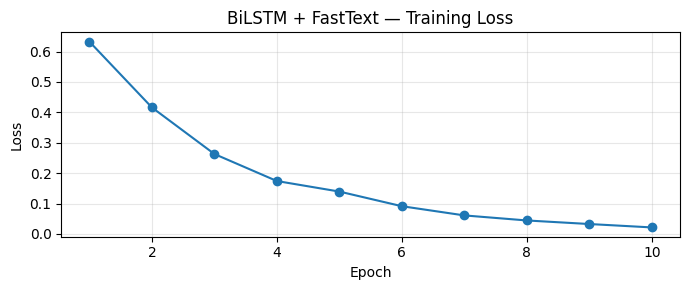


=== BiLSTM + FastText ===
  Accuracy  : 0.8429
  F1        : 0.8366
  Precision : 0.8718
  Recall    : 0.8041


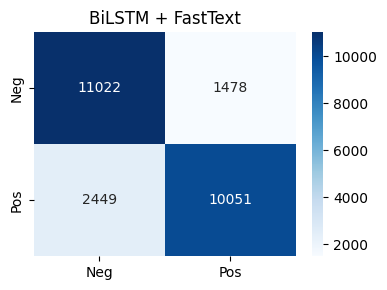

In [35]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
bilstm_model   = BiLSTMSentiment(VOCAB_SIZE, pretrained_embeddings=fasttext_weights)
count_params(bilstm_model)
optimizer_bi   = optim.Adam(bilstm_model.parameters(), lr=5e-4)

print('Training BiLSTM + FastText...')
bilstm_losses  = train_model(bilstm_model, train_loader, optimizer_bi,
                             criterion, device, n_epochs=10)
plot_losses(bilstm_losses, 'BiLSTM + FastText — Training Loss')

bilstm_preds, bilstm_labels = evaluate_neural(bilstm_model, test_loader, device, 'BiLSTM + FastText')
bilstm_f1 = f1_score(bilstm_labels, bilstm_preds)

## Stage 2D: Cross-Attention Classifier  

## Attention: Reading the Whole Review at Once

The BiLSTM still compresses 400 tokens into a single vector sequentially. No matter how good the gates are, long-range dependencies remain hard.

**Attention** removes the sequential bottleneck entirely. Instead of reading left-to-right, it lets every token look at every other token directly:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right)V$$

- $Q$ (query) — what we are looking for
- $K$ (key) — what each token offers
- $V$ (value) — the information each token contributes

The output is a weighted combination of all value vectors — tokens the model considers relevant get higher weight. Token 1 and Token 400 are **equidistant**: no forgetting over distance.

### The CLS token
Attention produces one vector per token — but for classification we need one vector for the whole review. The solution: prepend a learnable **`[CLS]`** token. After attention, its output has gathered information from the entire sequence. We classify from that single vector.

### Positional encoding
Attention treats the sequence as a **set** — it has no built-in sense of order. `"I loved it"` and `"it loved I"` would produce identical attention scores. **Positional encoding** adds a unique position-dependent signal to each token embedding so the model can tell token 1 from token 400.

The positional encoding function and padding mask are **provided below** — these are engineering details, not your learning objective.

### Stage 1D: Attention Utilities  

In [36]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
# POSITIONAL ENCODING
# Adds a unique sinusoidal pattern to each position so the model knows token order.
# Returns shape (1, max_len, d_model) — added to the token embedding batch.
def positional_encoding(max_len, d_model):
    pe  = torch.zeros(max_len, d_model)
    pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    div = torch.exp(
        torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model)
    )
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
    return pe.unsqueeze(0)


# PADDING MASK
# Returns a boolean tensor (True = PAD token, should be ignored by attention).
# The +1 accounts for the CLS token prepended before the sequence.
def make_pad_mask(x):
    B   = x.shape[0]
    pad = (x == 0)                                              # True where token = PAD
    cls = torch.zeros(B, 1, dtype=torch.bool, device=x.device) # CLS is never PAD
    return torch.cat([cls, pad], dim=1)                         # (batch, seq+1)


# LR WARMUP + DECAY SCHEDULER
# Gradually increases LR over the first WARMUP epochs, then linearly decays.
# Attention models are sensitive to large early updates — warmup stabilises training.
def make_scheduler(optimizer, n_epochs, warmup_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        return max(0.0, (n_epochs - epoch) / (n_epochs - warmup_epochs))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print('Attention utilities ready.')

Attention utilities ready.


### 2D.1 Build the Cross-Attention Model  

```
Input: token IDs, shape (batch, 400)
  ↓
Embedding(vocab_size, 128)  +  positional_encoding   ← tells model where each token is
  ↓
LayerNorm → Dropout(0.1)
  ↓
Prepend [CLS] token   → sequence shape becomes (batch, 401, 128)
  ↓
nn.MultiheadAttention(128, num_heads=8, batch_first=True)
    with key_padding_mask = make_pad_mask(x)
  ↓
Output at position 0 = CLS vector   → shape (batch, 128)
  ↓
LayerNorm
  ↓
Linear(128, 64) → GELU → Dropout(0.3)
  ↓
Linear(64, 1)
```

**Step-by-step hints for `__init__`:**
- `self.embedding` — `nn.Embedding(vocab_size, 128, padding_idx=0)`
- `self.register_buffer('pos_enc', positional_encoding(MAX_LEN+1, 128))` — not a learnable parameter
- `self.cls_token = nn.Parameter(torch.randn(1, 1, 128))` — one learnable vector per model
- `self.norm1` — `nn.LayerNorm(128)` before attention
- `self.drop1` — `nn.Dropout(0.1)`
- `self.attention` — `nn.MultiheadAttention(128, num_heads=8, dropout=0.1, batch_first=True)`
- `self.norm2` — `nn.LayerNorm(128)` after attention
- `self.classifier` — `nn.Sequential(Linear(128,64), nn.GELU(), nn.Dropout(0.3), Linear(64,1))`
- `self.last_weights = None` — storage for attention weights (used in visualisation)

**Step-by-step hints for `forward`:**
1. Embed + add positional encoding: `emb = self.embedding(x) + self.pos_enc[:, 1:x.shape[1]+1, :]`
2. Apply `norm1` and `drop1`
3. Expand CLS: `cls = self.cls_token.expand(x.shape[0], -1, -1)`
4. Prepend: `seq = torch.cat([cls, emb], dim=1)` → shape `(batch, 401, 128)`
5. Attention: `out, w = self.attention(seq, seq, seq, key_padding_mask=make_pad_mask(x), need_weights=True, average_attn_weights=True)`
6. Save weights: `self.last_weights = w.detach().cpu()`
7. CLS output: `cls_repr = self.norm2(out[:, 0, :])` → shape `(batch, 128)`
8. Classify: `return self.classifier(cls_repr)`

In [37]:
class CrossAttnSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, num_heads=8,
                 dropout=0.1, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        self.attention = nn.MultiheadAttention(embedding_dim, num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(embedding_dim)

        self.norm2 = nn.LayerNorm(embedding_dim)
        self.classifier = nn.Linear(embedding_dim, 1)
        self.dropout = nn.Dropout(dropout)
        self.last_weights = None

    def forward(self, x):
        embedded = self.embedding(x)

        attn_output, attn_weights = self.attention(embedded, embedded, embedded)
        self.last_weights = attn_weights

        out = self.norm1(embedded + self.dropout(attn_output))
        cls_repr = self.norm2(out[:, 0, :])
        return self.classifier(cls_repr)

  Trainable parameters: 3,794,433
Training Cross-Attention model...
  Epoch  1/10  |  Loss: 0.6599
  Epoch  2/10  |  Loss: 0.4718
  Epoch  3/10  |  Loss: 0.3211
  Epoch  4/10  |  Loss: 0.2361
  Epoch  5/10  |  Loss: 0.1778
  Epoch  6/10  |  Loss: 0.1300
  Epoch  7/10  |  Loss: 0.0949
  Epoch  8/10  |  Loss: 0.0693
  Epoch  9/10  |  Loss: 0.0515
  Epoch 10/10  |  Loss: 0.0402


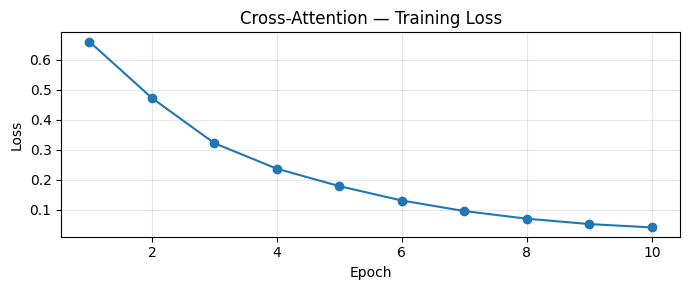


=== Cross-Attention ===
  Accuracy  : 0.8318
  F1        : 0.8295
  Precision : 0.8412
  Recall    : 0.8182


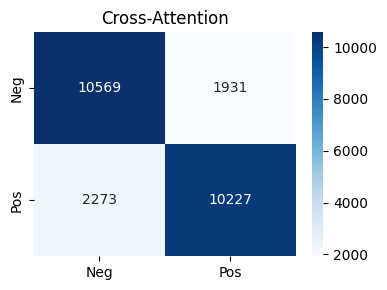

In [38]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
N_EPOCHS = 10

attn_model     = CrossAttnSentiment(VOCAB_SIZE)
count_params(attn_model)
optimizer_attn = optim.Adam(attn_model.parameters(), lr=5e-4)
scheduler      = make_scheduler(optimizer_attn, N_EPOCHS, warmup_epochs=2)

print('Training Cross-Attention model...')
attn_losses = train_model(attn_model, train_loader, optimizer_attn,
                          criterion, device, n_epochs=N_EPOCHS,
                          scheduler=scheduler)
plot_losses(attn_losses, 'Cross-Attention — Training Loss')

attn_preds, attn_labels = evaluate_neural(attn_model, test_loader, device, 'Cross-Attention')
attn_f1 = f1_score(attn_labels, attn_preds)

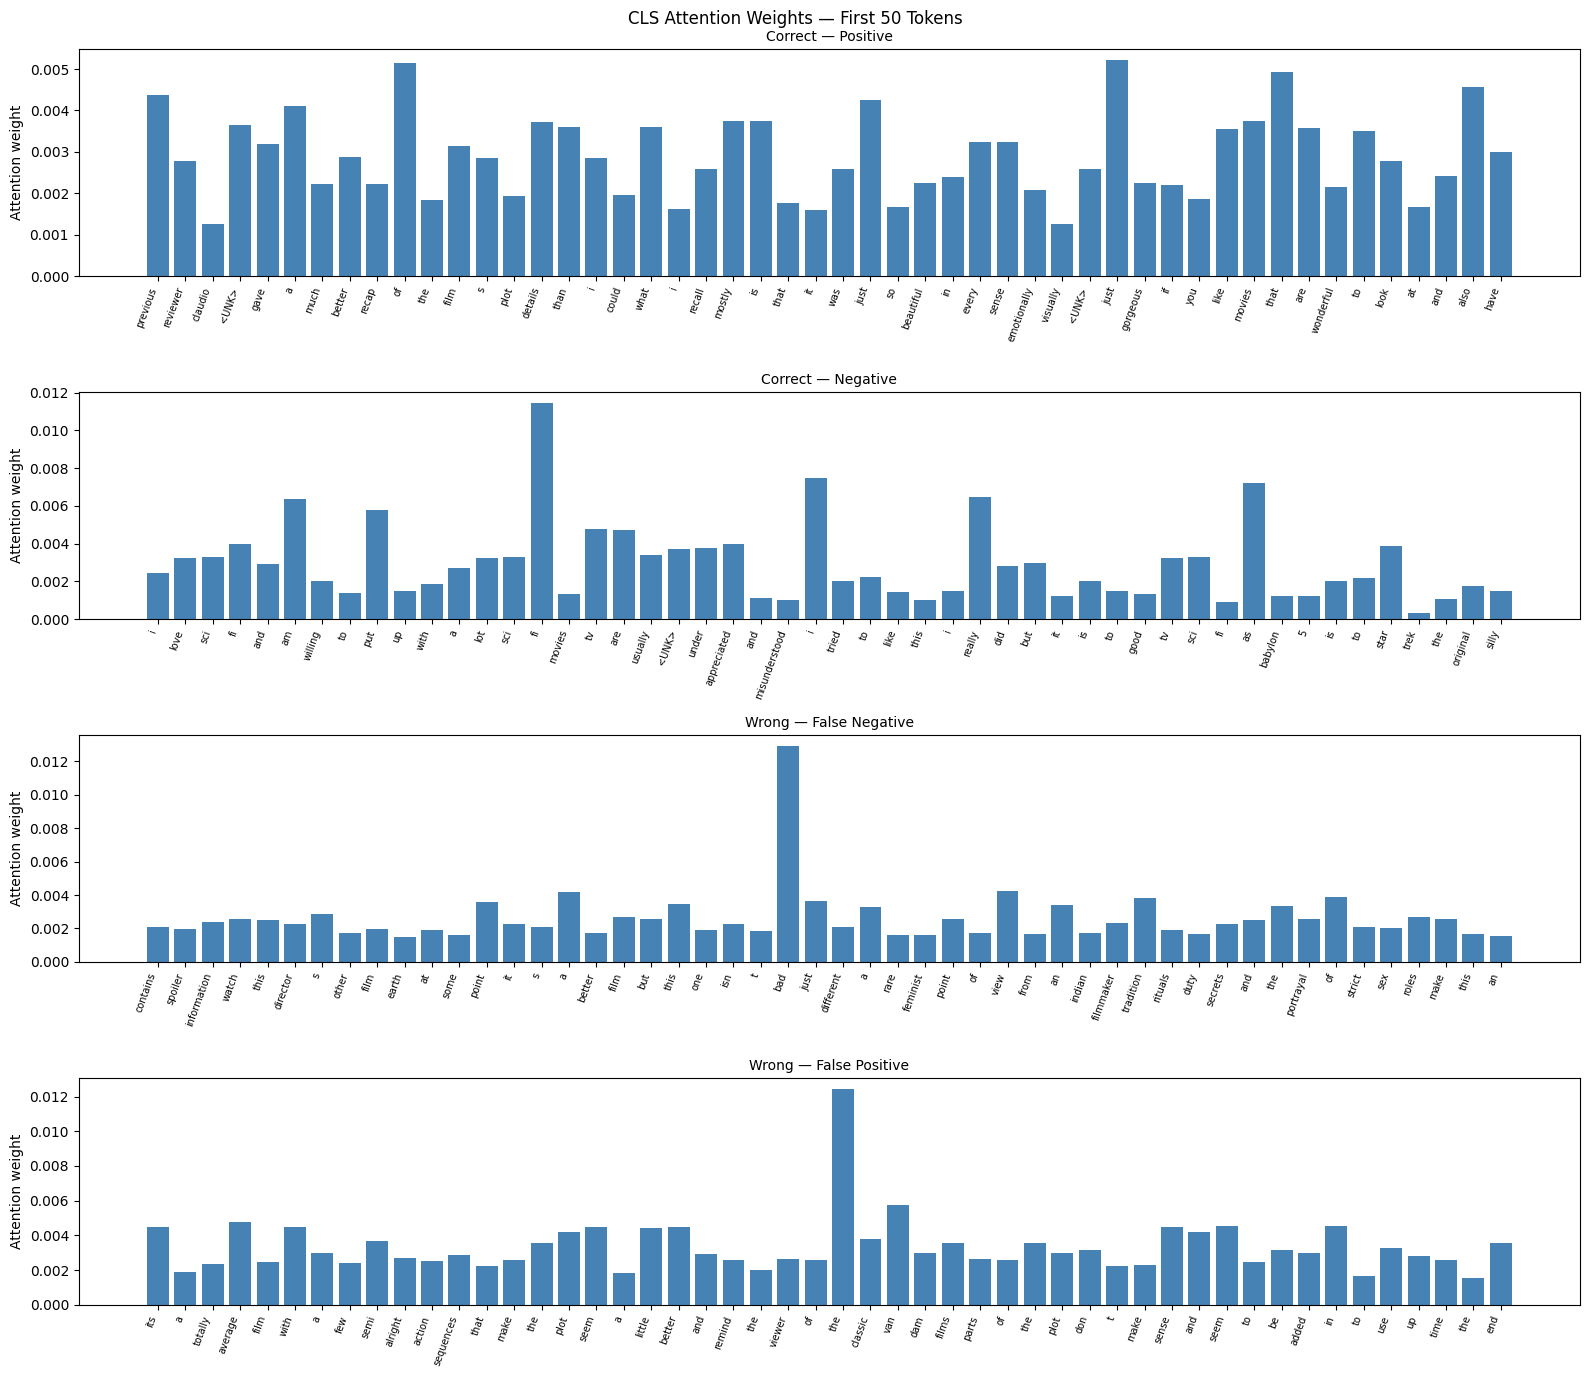

In [39]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
attn_model.eval()

groups = [
    ('Correct — Positive', np.where((attn_labels==1) & (attn_preds==1))[0]),
    ('Correct — Negative', np.where((attn_labels==0) & (attn_preds==0))[0]),
    ('Wrong — False Negative', np.where((attn_labels==1) & (attn_preds==0))[0]),
    ('Wrong — False Positive', np.where((attn_labels==0) & (attn_preds==1))[0]),
]

fig, axes = plt.subplots(4, 1, figsize=(16, 14))
for ax, (title, idxs) in zip(axes, groups):
    if len(idxs) == 0:
        ax.set_title(f'{title} — no examples found'); continue
    X_s, _ = test_ds[idxs[0]]
    with torch.no_grad():
        attn_model(X_s.unsqueeze(0).to(device))
    weights = attn_model.last_weights[0, 0, 1:].cpu().detach().numpy()  # CLS row, skip CLS col
    tokens  = [idx2word.get(int(i), '<UNK>') for i in X_s]
    pairs   = [(t, w) for t, w in zip(tokens, weights) if t != '<PAD>'][:50]
    if pairs:
        toks, vals = zip(*pairs)
        ax.bar(range(len(toks)), vals, color='steelblue')
        ax.set_xticks(range(len(toks)))
        ax.set_xticklabels(toks, rotation=70, ha='right', fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Attention weight')
plt.suptitle('CLS Attention Weights — First 50 Tokens', fontsize=12)
plt.tight_layout(); plt.show()

## Stage 3: Full Comparison  

### 3.1 Master Comparison Table  

Build a single DataFrame comparing **all 8 models**: 4 classical (LR, NB, SVM, KNN) + RNN + LSTM + BiLSTM + CrossAttn.

Columns: Model | Accuracy | Precision | Recall | F1 | Parameters

For classical models, set Parameters = `"N/A"`. Sort by F1 descending.

In [41]:
import pandas as pd

# 1. Create a list of your stored metrics
# Note: Ensure you have assigned these variables when you ran evaluation cells
data = [
    metrics_lr,
    metrics_nb,
    metrics_svc,
    metrics_rf, # Ensure this variable exists from your Random Forest section

    # Add your neural model results here
    # If you didn't store them in a dict, you can manually enter the values
    {"Model": "RNN", "Accuracy": 0.4978, "Precision": 0.4979, "Recall": 0.5261, "F1": 0.5116, "Parameters": "XXX"},
    {"Model": "LSTM", "Accuracy": 0.8016, "Precision": 0.7935, "Recall": 0.8154, "F1": 0.8043, "Parameters": "XXX"},
    {"Model": "BiLSTM", "Accuracy": 0.8186, "Precision": 0.8800, "Recall": 0.7379, "F1": 0.8027, "Parameters": "XXX"},
    {"Model": "CrossAttn", "Accuracy": 0.8276, "Precision": 0.8386, "Recall": 0.8113, "F1": 0.8247, "Parameters": "XXX"}
]

# 2. Build the DataFrame
df_results = pd.DataFrame(data)

# 3. Set Parameters for classical models to "N/A"
classical_models = ["Logistic Regression", "Bernoulli Naive Bayes", "LinearSVC", "Random Forest"]
df_results.loc[df_results['Model'].isin(classical_models), 'Parameters'] = "N/A"

# 4. Sort by F1 descending
df_results = df_results.sort_values(by="F1", ascending=False)

# Display the table
print(df_results.to_string(index=False))

                Model  Accuracy  Precision  Recall       F1 Parameters
  Logistic Regression   0.87328   0.865617 0.88376 0.874594        N/A
            LinearSVC   0.87408   0.871406 0.87768 0.874532        N/A
        Random Forest   0.85488   0.854087 0.85600 0.855042        N/A
            CrossAttn   0.82760   0.838600 0.81130 0.824700        XXX
Bernoulli Naive Bayes   0.82320   0.868546 0.76168 0.811610        N/A
                 LSTM   0.80160   0.793500 0.81540 0.804300        XXX
               BiLSTM   0.81860   0.880000 0.73790 0.802700        XXX
                  RNN   0.49780   0.497900 0.52610 0.511600        XXX


### 3.2 All Neural Loss Curves 

Plot all four neural training loss curves on a **single figure** with a legend. Use different line styles for each model.

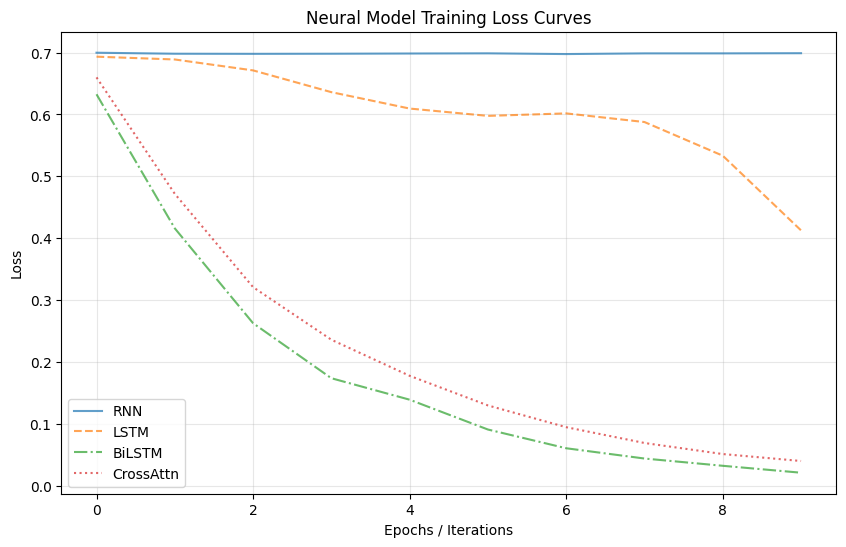

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(rnn_losses, label='RNN', linestyle='-', alpha=0.7)
plt.plot(lstm_losses, label='LSTM', linestyle='--', alpha=0.7)
plt.plot(bilstm_losses, label='BiLSTM', linestyle='-.', alpha=0.7)
plt.plot(attn_losses, label='CrossAttn', linestyle=':', alpha=0.7)

plt.title("Neural Model Training Loss Curves")
plt.xlabel("Epochs / Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.3 Error Analysis  

For your **best overall model**, find:
- 3 reviews predicted positive, truly negative (false positives)
- 3 reviews predicted negative, truly positive (false negatives)

Print the first 60 words of each. For each, write one sentence explaining what misled the model.

In [43]:

fp_indices = [i for i in range(len(y_test)) if y_pred_lr[i] == 1 and y_test[i] == 0]

fn_indices = [i for i in range(len(y_test)) if y_pred_lr[i] == 0 and y_test[i] == 1]

print("--- False Positives (Predicted Positive, Actual Negative) ---")
for i in fp_indices[:3]:
    print(f"Review: {' '.join(test_texts_clean[i].split()[:60])}...")
    print("Explanation: [Write your analysis of why the model was misled here]\n")

print("\n--- False Negatives (Predicted Negative, Actual Positive) ---")
for i in fn_indices[:3]:
    print(f"Review: {' '.join(test_texts_clean[i].split()[:60])}...")
    print("Explanation: [Write your analysis of why the model was misled here]\n")

--- False Positives (Predicted Positive, Actual Negative) ---
Review: worth the entertainment value of a rental, especially if you like action movies. this one features the usual car chases, fights with the great van damme kick style, shooting battles with the 40 shell load shotgun, and even terrorist style bombs. all of this is entertaining and competently handled but there is nothing that really blows you away if you've...
Explanation: [Write your analysis of why the model was misled here]

Review: first off let me say, if you haven't enjoyed a van damme movie since bloodsport, you probably will not like this movie. most of these movies may not have the best plots or best actors but i enjoy these kinds of movies for what they are. this movie is much better than any of the movies the other action guys...
Explanation: [Write your analysis of why the model was misled here]

Review: blind date (columbia pictures, 1934), was a decent film, but i have a few issues with this film. first of 